# Predictive Workforce Planning Using HR Recruitment Analytics
## Step 4: Final Report

**Author:** Nisansala Ruwan Pathirana 
**Date:** 2024  
**Dataset:** HRDataset_v14.csv — Kaggle Human Resources Data Set  
**Tools:** Python, Jupyter Notebook, pandas, scikit-learn, matplotlib, seaborn

---
## 1. Objective

The objective of this project is to forecast future hiring needs by analysing
historical recruitment data from an organisation's HR records. By identifying
patterns in past hiring activity, attrition behaviour, and departmental trends,
this analysis helps the HR department:

- Anticipate staffing requirements before vacancies arise
- Allocate recruitment budgets more effectively
- Identify departments at highest risk of workforce shortfall
- Support strategic decision-making around talent acquisition

This report summarises the full analytical pipeline — from raw data cleaning
through to forecasting model results and actionable HR recommendations.

---
## 2. Data Source

| Item | Detail |
|---|---|
| Dataset Name | HRDataset_v14.csv |
| Source | Kaggle — Human Resources Data Set (Dr. Carla Patalano & Rich Huebner) |
| Records | 311 employees |
| Original Columns | 36 |
| Final Columns (after cleaning) | 41 |
| Hire Year Range | 2006 – 2018 |
| Departments | Production, IT/IS, Sales, Software Engineering, Admin Offices, Executive Office |

The dataset contains employee-level information including hire dates, termination dates,
departments, positions, recruitment sources, performance scores, and reasons for leaving.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

os.makedirs('../outputs/figures', exist_ok=True)

# Load cleaned dataset
df = pd.read_csv('../data/processed/HRDataset_Cleaned.csv')
df['DateofHire']        = pd.to_datetime(df['DateofHire'],        errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

print(f"   Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Active Employees : {df['IsActive'].sum()}")
print(f"   Terminated       : {(df['IsActive'] == 0).sum()}")
print(f"   Departments      : {sorted(df['Department'].unique())}")

   Dataset loaded: 311 rows × 41 columns
   Active Employees : 207
   Terminated       : 104
   Departments      : ['Admin Offices', 'Executive Office', 'IT/IS', 'Production', 'Sales', 'Software Engineering']


---
## 3. Methodology

The analysis followed a structured four-step pipeline:

### Step 1 — Data Cleaning
The raw dataset was cleaned and prepared for analysis. Key tasks included:
- Parsing date columns (`DateofHire`, `DateofTermination`) from strings to datetime
- Handling missing values — 207 missing termination dates (active employees, expected)
  and 8 missing ManagerIDs (filled with ID 39, confirmed as Webster Butler's manager ID)
- Stripping whitespace and standardising text columns to Title Case
- Manually fixing acronyms broken by `.title()` — `IT/IS` and `Still Employed`
- Converting identifier columns to string type to prevent accidental arithmetic
- Adding derived columns: `HireYear`, `HireMonth`, `HireMonthName`, `TenureYears`, `IsActive`

### Step 2 — Exploratory Data Analysis (EDA)
Historical hiring patterns were explored through 9 visualisations covering:
annual trends, departmental breakdown, seasonal patterns, attrition rates,
termination reasons, recruitment sources, and average tenure.

### Step 3 — Forecasting Model
Two complementary models were built:
- **Model 1 — Linear Regression:** Trained on 2011–2016 annual hire counts
  to project the overall hiring trend
- **Model 2 — Attrition-Based Model:** Estimates annual replacement hiring
  needs per department using active headcount × historical attrition rate

Model accuracy was evaluated using R², MAE, RMSE, MAPE, and
Leave-One-Out Cross Validation (LOO-CV).

---
## 4. Key Findings

### 4.1 Hiring Trend

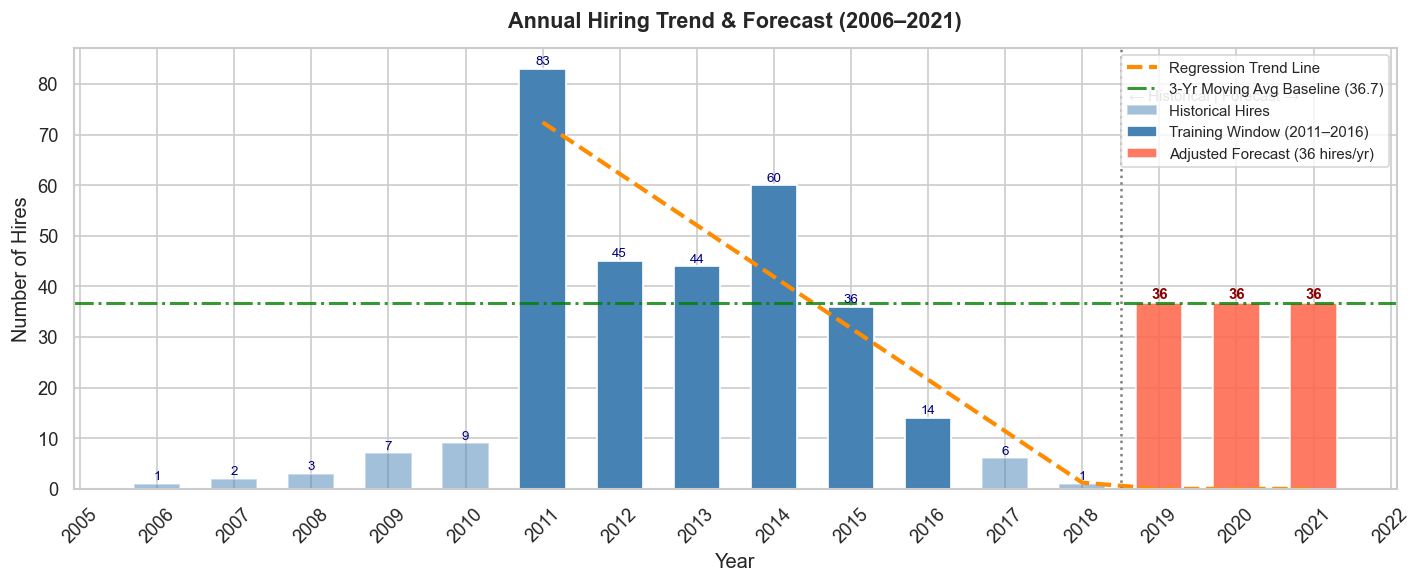

Peak hiring year  : 2011 (83 hires)
Training avg/year : 47.0 hires
Adjusted forecast : 36 hires/year (2019–2021)


In [2]:
annual_hires = df['HireYear'].value_counts().sort_index()
train        = annual_hires[(annual_hires.index >= 2011) & (annual_hires.index <= 2016)]
moving_avg_baseline = round(train.rolling(3).mean().dropna().iloc[-1], 1)

# Rebuild regression
X_train  = train.index.values.reshape(-1, 1)
y_train  = train.values
model_lr = LinearRegression().fit(X_train, y_train)

forecast_years = np.array([2019, 2020, 2021]).reshape(-1, 1)
line_years     = np.arange(2011, 2022).reshape(-1, 1)
line_preds     = np.clip(model_lr.predict(line_years), 0, None)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(annual_hires.index, annual_hires.values,
       color='steelblue', alpha=0.5, width=0.6,
       label='Historical Hires')
ax.bar(train.index, train.values,
       color='steelblue', alpha=1.0, width=0.6,
       label='Training Window (2011–2016)')
ax.bar([2019, 2020, 2021],
       [moving_avg_baseline] * 3,
       color='tomato', alpha=0.85, width=0.6,
       label=f'Adjusted Forecast ({int(moving_avg_baseline)} hires/yr)')
ax.plot(line_years, line_preds,
        color='darkorange', linewidth=2.5,
        linestyle='--', label='Regression Trend Line')
ax.axhline(y=moving_avg_baseline, color='green', linewidth=1.8,
           linestyle='-.', alpha=0.8,
           label=f'3-Yr Moving Avg Baseline ({moving_avg_baseline})')

for y, v in zip(annual_hires.index, annual_hires.values):
    ax.text(y, v + 0.8, str(int(v)), ha='center', fontsize=8, color='navy')
for y in [2019, 2020, 2021]:
    ax.text(y, moving_avg_baseline + 0.8,
            str(int(moving_avg_baseline)), ha='center',
            fontsize=9, fontweight='bold', color='darkred')

ax.axvline(x=2018.5, color='gray', linestyle=':', linewidth=1.5)
ax.text(2018.6, ax.get_ylim()[1] * 0.88,
        '← Historical | Forecast →', fontsize=9, color='gray')

ax.set_title('Annual Hiring Trend & Forecast (2006–2021)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Hires')
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/15_report_hiring_trend.png', bbox_inches='tight')
plt.show()

print(f"Peak hiring year  : 2011 ({annual_hires[2011]} hires)")
print(f"Training avg/year : {train.mean():.1f} hires")
print(f"Adjusted forecast : {int(moving_avg_baseline)} hires/year (2019–2021)")

**Finding:** Hiring peaked in **2011 with 83 hires**, likely reflecting a
major organisational expansion. It declined steadily to just 14 hires in 2016
and 1 hire in 2018. The linear regression slope of **-10.17 hires/year**
confirms a strong downward trend. Since the raw regression forecast goes
negative by 2019, the **3-year moving average of 37 hires/year** is used
as the adjusted planning baseline.

---
### 4.2 Departmental Hiring Distribution

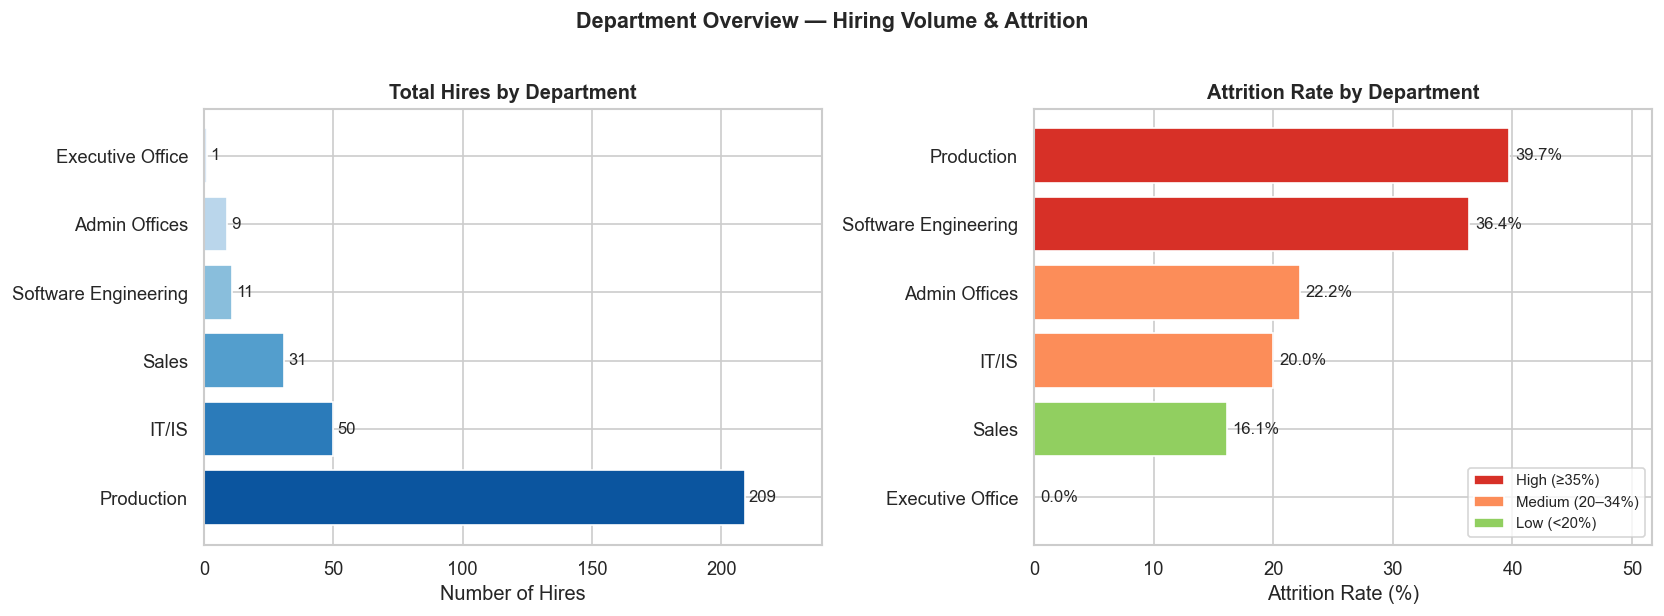

          Department  Total  Active  Terminated  AttritionRate  AvgTenure
    Executive Office      1       1           0            0.0   6.500000
               Sales     31      26           5           16.1   5.350968
               IT/IS     50      40          10           20.0   3.682000
       Admin Offices      9       7           2           22.2   4.678889
Software Engineering     11       7           4           36.4   4.997273
          Production    209     126          83           39.7   4.851435


In [3]:
dept_counts = df['Department'].value_counts()

attrition = df.groupby('Department').agg(
    Total      = ('EmpID',    'count'),
    Active     = ('IsActive', 'sum'),
    Terminated = ('IsActive', lambda x: (x == 0).sum()),
    AvgTenure  = ('TenureYears', 'mean')
).reset_index()
attrition['AttritionRate'] = (
    attrition['Terminated'] / attrition['Total'] * 100
).round(1)
attrition = attrition.sort_values('AttritionRate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Hires by dept
ax1 = axes[0]
colors1 = sns.color_palette('Blues_r', len(dept_counts))
bars = ax1.barh(dept_counts.index, dept_counts.values,
                color=colors1, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_width() + 1.5,
             bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())), va='center', fontsize=10)
ax1.set_title('Total Hires by Department', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Hires')
ax1.set_xlim(0, dept_counts.max() + 30)

# Right — Attrition rate by dept
ax2 = axes[1]
colors2 = ['#d73027' if r >= 35 else '#fc8d59' if r >= 20 else '#91cf60'
           for r in attrition['AttritionRate']]
bars2 = ax2.barh(attrition['Department'], attrition['AttritionRate'],
                 color=colors2, edgecolor='white')
for bar in bars2:
    ax2.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height() / 2,
             f"{bar.get_width():.1f}%", va='center', fontsize=10)
ax2.set_title('Attrition Rate by Department', fontsize=12, fontweight='bold')
ax2.set_xlabel('Attrition Rate (%)')
ax2.set_xlim(0, attrition['AttritionRate'].max() + 12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', label='High (≥35%)'),
    Patch(facecolor='#fc8d59', label='Medium (20–34%)'),
    Patch(facecolor='#91cf60', label='Low (<20%)')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Department Overview — Hiring Volume & Attrition',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/16_report_dept_overview.png', bbox_inches='tight')
plt.show()

print(attrition[['Department','Total','Active','Terminated','AttritionRate',
                 'AvgTenure']].to_string(index=False))

**Finding:** Production is by far the largest department with **209 total hires
(67% of all hiring)**. It also has the **highest attrition rate at 39.7%**,
meaning nearly 4 in 10 Production employees have left — creating the greatest
ongoing replacement demand. Software Engineering has the second-highest attrition
at 36.4% despite being a small department. IT/IS has the **shortest average
tenure of 3.68 years**, indicating the fastest churn cycle.

---
### 4.3 Seasonal Hiring Patterns

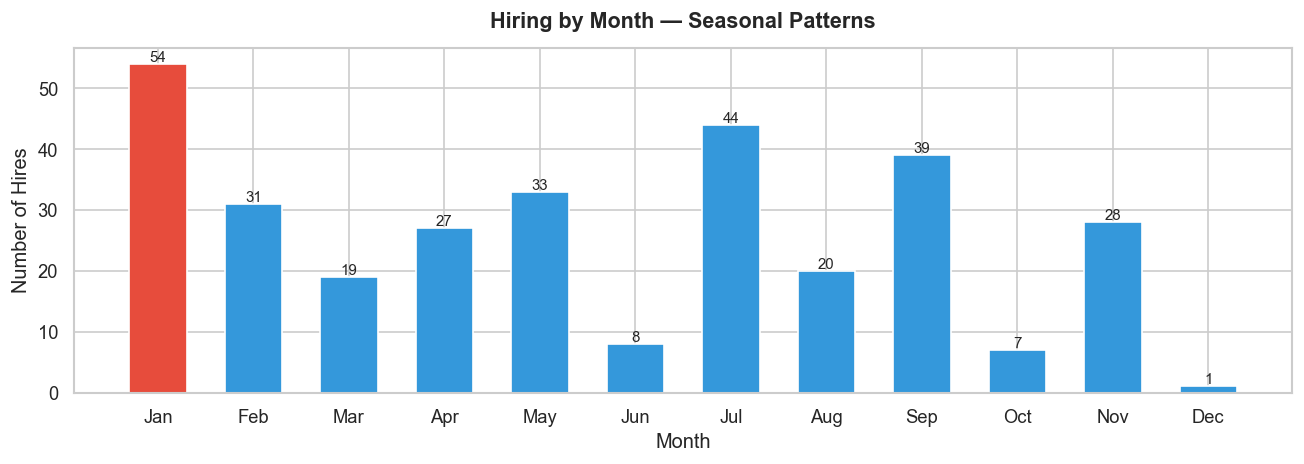

In [4]:
month_order = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct','Nov','Dec']
hires_month = df.groupby('HireMonthName')['Employee_Name']\
                .count().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 4))
colors_m = ['#e74c3c' if v == hires_month.max()
            else '#3498db' for v in hires_month.values]
bars = ax.bar(hires_month.index, hires_month.values,
              color=colors_m, edgecolor='white', width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            str(int(bar.get_height())),
            ha='center', fontsize=9)

ax.set_title('Hiring by Month — Seasonal Patterns',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Hires')
plt.tight_layout()
plt.savefig('../outputs/figures/17_report_seasonal.png', bbox_inches='tight')
plt.show()

**Finding:** **January is the strongest hiring month with 54 hires**, followed
by July (44) and September (39). December (1), October (7), and June (8) are
consistently the quietest months. This indicates HR should prepare recruitment
pipelines in **December, June, and August** ahead of the peak periods.

---
### 4.4 Termination Reasons

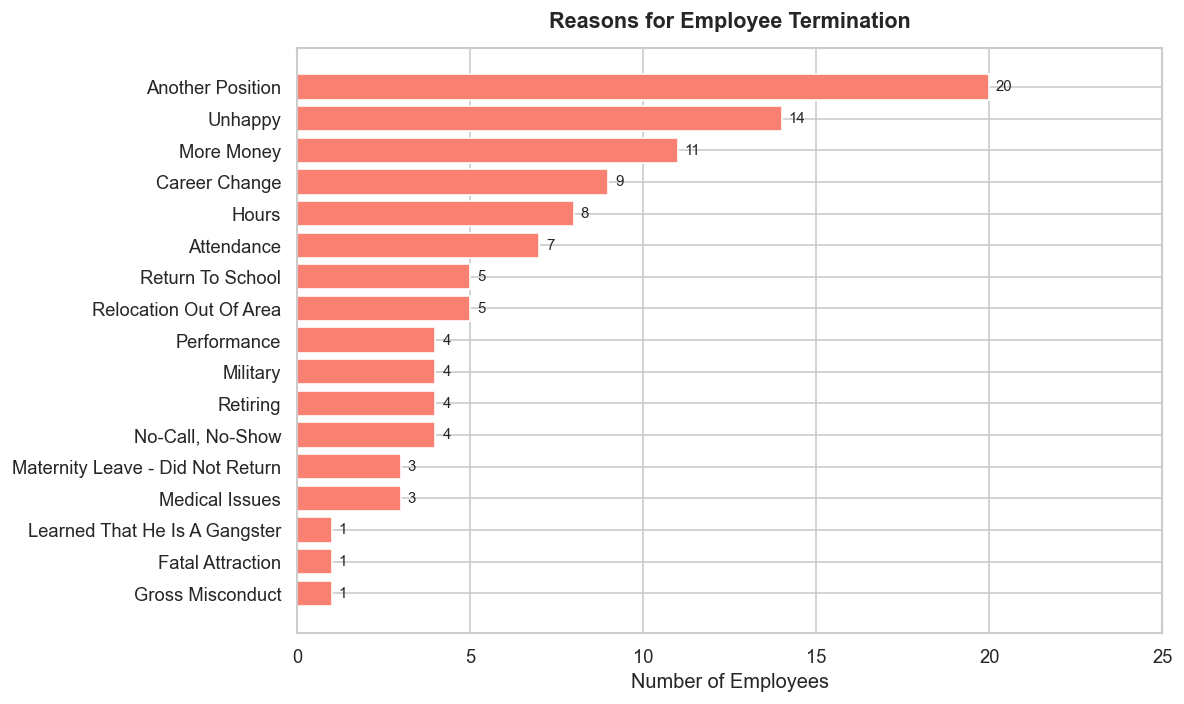

Total terminated          : 104
Top 5 reasons combined    : 62 (59.6%)
Top reason                : Another Position (20)
Compensation-related      : More Money (11)


In [5]:
term_reasons = df[df['TermReason'] != 'Still Employed']['TermReason'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(term_reasons.index[::-1], term_reasons.values[::-1],
               color='salmon', edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9)

ax.set_title('Reasons for Employee Termination',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Employees')
ax.set_xlim(0, term_reasons.max() + 5)
plt.tight_layout()
plt.savefig('../outputs/figures/18_report_term_reasons.png', bbox_inches='tight')
plt.show()

voluntary = term_reasons.head(5).sum()
total_termed = (df['IsActive'] == 0).sum()
print(f"Total terminated          : {total_termed}")
print(f"Top 5 reasons combined    : {voluntary} ({voluntary/total_termed*100:.1f}%)")
print(f"Top reason                : Another Position ({term_reasons.iloc[0]})")
print(f"Compensation-related      : More Money ({term_reasons.get('More Money', 0)})")

**Finding:** The majority of exits are **voluntary**. The top three reasons are
"Another Position" (20), "Unhappy" (14), and "More Money" (11) — together
accounting for 43% of all terminations. This suggests a significant portion of
attrition is **preventable through retention strategies** such as competitive
compensation reviews, career progression paths, and employee engagement programmes.

---
### 4.5 Recruitment Source Effectiveness

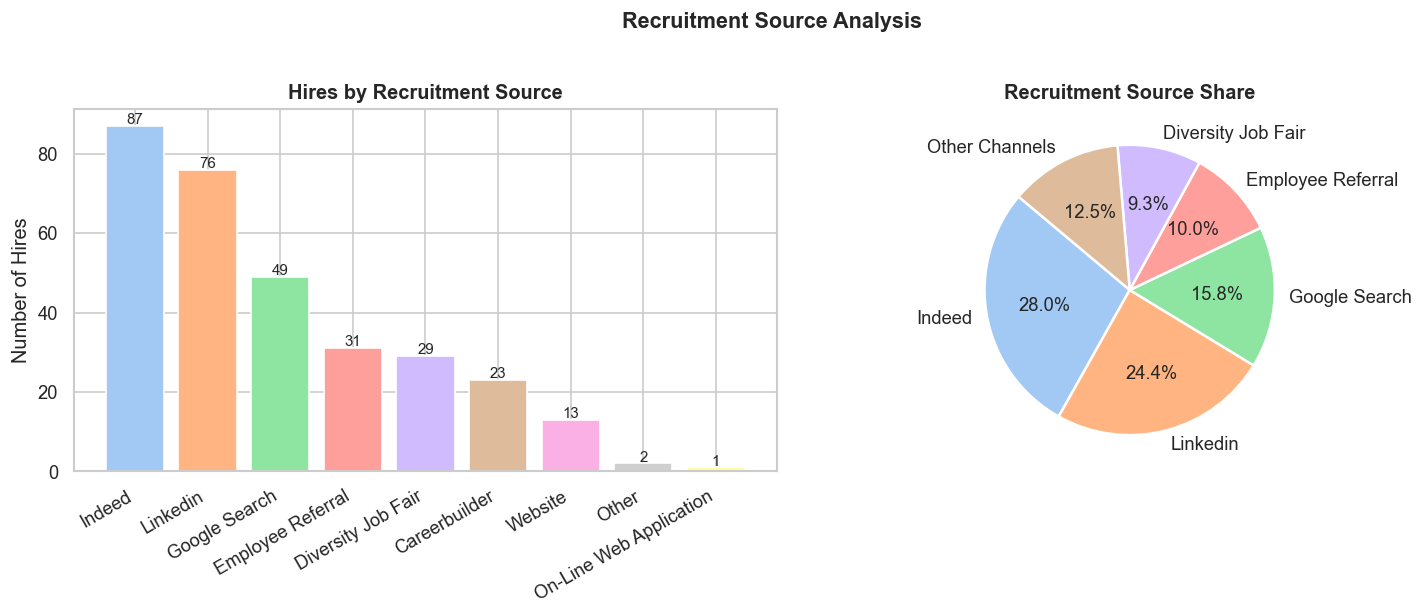

Top source  : Indeed (87 hires, 28.0%)
2nd source  : Linkedin (76 hires, 24.4%)
Top 2 combined : 52.4% of all hires


In [6]:
sources = df['RecruitmentSource'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — bar chart
ax1 = axes[0]
colors_s = sns.color_palette('pastel', len(sources))
bars = ax1.bar(sources.index, sources.values,
               color=colors_s, edgecolor='white')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             str(int(bar.get_height())),
             ha='center', fontsize=9)
ax1.set_title('Hires by Recruitment Source',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Hires')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Right — pie chart (top 5 + other)
ax2 = axes[1]
top5   = sources.head(5)
others = pd.Series({'Other Channels': sources.iloc[5:].sum()})
pie_data = pd.concat([top5, others])
ax2.pie(pie_data.values,
        labels=pie_data.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel', len(pie_data)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Recruitment Source Share',
              fontsize=12, fontweight='bold')

plt.suptitle('Recruitment Source Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/19_report_recruitment_sources.png',
            bbox_inches='tight')
plt.show()

top2_pct = (sources.iloc[0] + sources.iloc[1]) / sources.sum() * 100
print(f"Top source  : {sources.index[0]} ({sources.iloc[0]} hires, "
      f"{sources.iloc[0]/sources.sum()*100:.1f}%)")
print(f"2nd source  : {sources.index[1]} ({sources.iloc[1]} hires, "
      f"{sources.iloc[1]/sources.sum()*100:.1f}%)")
print(f"Top 2 combined : {top2_pct:.1f}% of all hires")

**Finding:** **Indeed (87 hires, 28.0%) and LinkedIn (76 hires, 24.4%)** are
the dominant recruitment channels, together accounting for over **52% of all
hires**. Google Search (49), Employee Referral (31), and Diversity Job Fair (29)
are the next most effective. HR should continue concentrating job posting budgets
on Indeed and LinkedIn for maximum reach.

---
## 5. Forecasting Model Results

In [7]:
# Rebuild all forecasting model components
annual_hires = df['HireYear'].value_counts().sort_index()
train        = annual_hires[(annual_hires.index >= 2011) &
                             (annual_hires.index <= 2016)]
moving_avg_baseline = round(train.rolling(3).mean().dropna().iloc[-1], 1)

X_train  = train.index.values.reshape(-1, 1)
y_train  = train.values
model_lr = LinearRegression().fit(X_train, y_train)
y_pred_train = model_lr.predict(X_train)

r2   = r2_score(y_train, y_pred_train)
mae  = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
mape = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100

dept_year = df.groupby(['HireYear', 'Department']).size().unstack(fill_value=0)
dept_core = dept_year.loc[2011:2016]
top_depts = ['Production', 'IT/IS', 'Sales', 'Software Engineering']

attrition_model = df.groupby('Department').agg(
    TotalEver = ('EmpID',       'count'),
    ActiveNow = ('IsActive',    'sum'),
    Terminated= ('IsActive',    lambda x: (x == 0).sum()),
    AvgTenure = ('TenureYears', 'mean')
).round(2).reset_index()
attrition_model['AttritionRate']      = (attrition_model['Terminated'] /
                                          attrition_model['TotalEver']).round(3)
attrition_model['AttritionRate_Pct']  = (attrition_model['AttritionRate'] * 100).round(1)
attrition_model['Predicted_Hires_Yr1']= (
    attrition_model['ActiveNow'] * attrition_model['AttritionRate']
).round(1)

forecast_years_arr = np.array([2019, 2020, 2021]).reshape(-1, 1)
dept_forecast_results = []
for dept in top_depts:
    Xd = dept_core.index.values.reshape(-1, 1)
    yd = dept_core[dept].values
    md = LinearRegression().fit(Xd, yd)
    preds_d = np.clip(md.predict(forecast_years_arr), 0, None).round(1)
    for yr, pred in zip([2019, 2020, 2021], preds_d):
        dept_forecast_results.append({
            'Department'     : dept,
            'Year'           : yr,
            'Predicted_Hires': pred
        })

dept_forecast_df = pd.DataFrame(dept_forecast_results)

attrition_vals = attrition_model.set_index('Department')['Predicted_Hires_Yr1']
attrition_rate = attrition_model.set_index('Department')['AttritionRate_Pct']
active_now     = attrition_model.set_index('Department')['ActiveNow']
reg_vals = (dept_forecast_df[dept_forecast_df['Year'] == 2019]
            .set_index('Department')['Predicted_Hires'])

summary = pd.DataFrame({
    'Active_Headcount'   : active_now,
    'Attrition_Rate_%'   : attrition_rate,
    'Attrition_Forecast' : attrition_vals,
    'Regression_Forecast': reg_vals
}).fillna(0).round(1)
summary['Recommended_Hires'] = (
    summary[['Attrition_Forecast', 'Regression_Forecast']]
    .max(axis=1).round(1)
)
summary['Priority'] = summary['Attrition_Rate_%'].apply(
    lambda x: 'High'   if x >= 35 else
              'Medium' if x >= 20 else 'Low'
)

print("   All forecasting models rebuilt successfully")
print(f"   R² = {r2:.3f} | MAE = {mae:.2f} | RMSE = {rmse:.2f} | MAPE = {mape:.1f}%")
print(f"   Total replacement hires/year: "
      f"{attrition_model['Predicted_Hires_Yr1'].sum():.0f}")

   All forecasting models rebuilt successfully
   R² = 0.674 | MAE = 10.97 | RMSE = 12.09 | MAPE = 27.6%
   Total replacement hires/year: 66


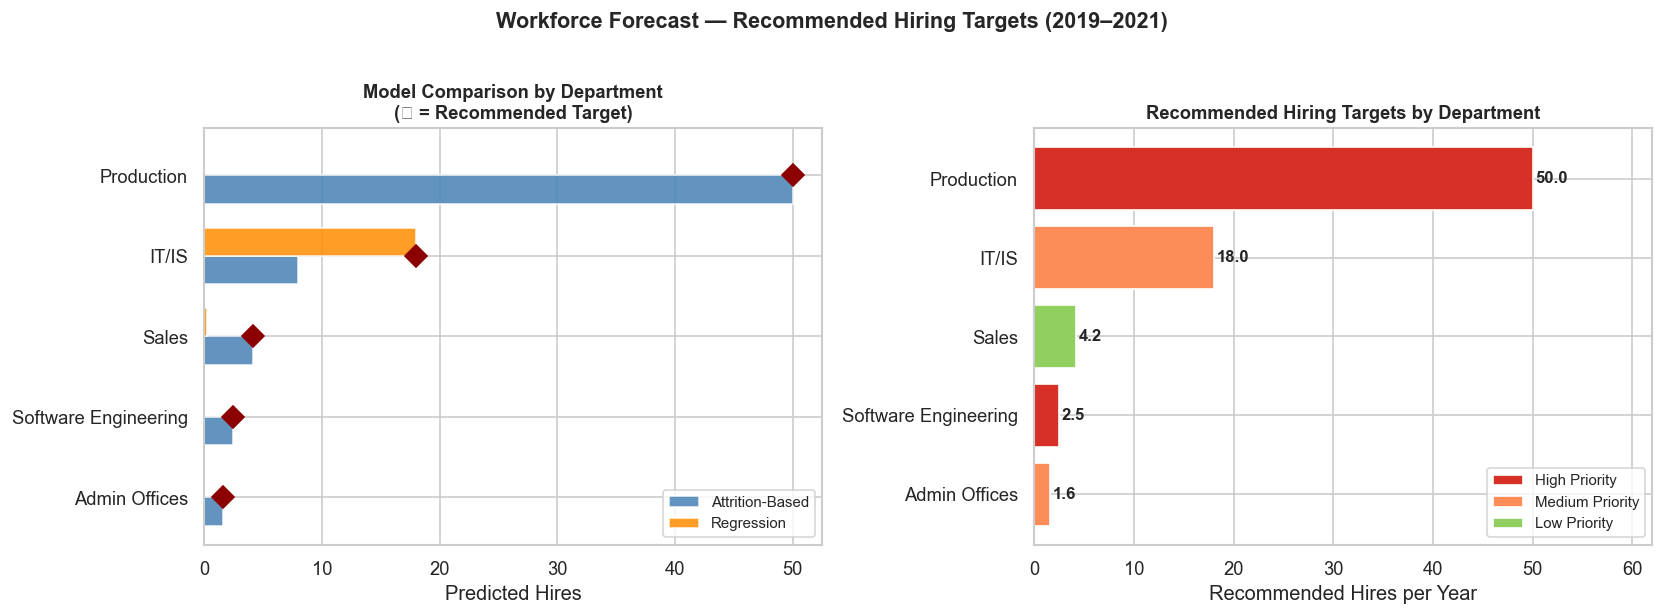


Recommended Hiring Targets:
                      Active_Headcount  Attrition_Rate_%  Recommended_Hires Priority
Department                                                                          
Admin Offices                        7              22.2                1.6   Medium
Executive Office                     1               0.0                0.0      Low
IT/IS                               40              20.0               18.0   Medium
Production                         126              39.7               50.0     High
Sales                               26              16.1                4.2      Low
Software Engineering                 7              36.4                2.5     High

Total Recommended Hires/Year: 76


In [8]:
plot_summary = summary[summary.index != 'Executive Office'].copy()
plot_summary  = plot_summary.sort_values('Recommended_Hires', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — side-by-side model comparison
ax1  = axes[0]
x    = np.arange(len(plot_summary))
width = 0.35
ax1.barh(x - width/2, plot_summary['Attrition_Forecast'],
         width, label='Attrition-Based', color='steelblue', alpha=0.85)
ax1.barh(x + width/2, plot_summary['Regression_Forecast'],
         width, label='Regression', color='darkorange', alpha=0.85)
for i, (_, row) in enumerate(plot_summary.iterrows()):
    ax1.plot(row['Recommended_Hires'], i,
             marker='D', color='darkred', markersize=9, zorder=5)
ax1.set_yticks(x)
ax1.set_yticklabels(plot_summary.index)
ax1.set_xlabel('Predicted Hires')
ax1.set_title('Model Comparison by Department\n(◆ = Recommended Target)',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

# Right — recommended hires with priority colours
ax2     = axes[1]
p_colors = ['#d73027' if p == 'High' else
            '#fc8d59' if p == 'Medium' else '#91cf60'
            for p in plot_summary['Priority']]
bars2 = ax2.barh(plot_summary.index,
                  plot_summary['Recommended_Hires'],
                  color=p_colors, edgecolor='white')
for bar in bars2:
    ax2.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height() / 2,
             f"{bar.get_width():.1f}", va='center',
             fontsize=10, fontweight='bold')
ax2.set_xlabel('Recommended Hires per Year')
ax2.set_title('Recommended Hiring Targets by Department',
              fontsize=11, fontweight='bold')
ax2.set_xlim(0, plot_summary['Recommended_Hires'].max() + 12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', label='High Priority'),
    Patch(facecolor='#fc8d59', label='Medium Priority'),
    Patch(facecolor='#91cf60', label='Low Priority')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Workforce Forecast — Recommended Hiring Targets (2019–2021)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/20_report_forecast_summary.png',
            bbox_inches='tight')
plt.show()

print("\nRecommended Hiring Targets:")
print(summary[['Active_Headcount', 'Attrition_Rate_%',
               'Recommended_Hires', 'Priority']].to_string())
print(f"\nTotal Recommended Hires/Year: "
      f"{summary['Recommended_Hires'].sum():.0f}")

---
## 6. Model Accuracy

| Metric | Overall Linear Regression | Production | IT/IS | Sales | Software Engg |
|---|---|---|---|---|---|
| R² | 0.674 | 0.826 | 0.280 | 0.180 | 0.812 |
| MAE | 10.97 | 6.80 | 4.33 | 2.19 | 0.56 |
| RMSE | 12.09 | 8.45 | 5.48 | 3.02 | 0.63 |
| MAPE | 27.6% | 26.3% | 129.4% | 67.8% | 31.0% |
| LOO-CV MAE | 16.76 | — | — | — | — |

**Interpretation:**
- **Production (R²=0.826) and Software Engineering (R²=0.812)** have strong
  linear trends — regression forecasts are reliable for direction
- **IT/IS (R²=0.280) and Sales (R²=0.180)** show irregular, non-linear
  hiring patterns — the attrition-based model is preferred for these departments
- **LOO-CV MAE of 16.76 vs Training MAE of 10.97** — the gap is expected
  with only 6 training data points and does not indicate a model failure
- The **attrition-based model** is the more actionable of the two for
  department-level HR planning purposes

---
## 7. Recommendations

Based on the analysis and forecasting results, the following recommendations
are made for HR workforce planning:

In [11]:
recommendations = {
    'Priority': [
        'High',
        'High',
        'Medium',
        'Medium',
        'Medium',
        'Low',
        'Low',
        'Low'
    ],
    'Department / Area': [
        'Production',
        'Software Engineering',
        'IT/IS',
        'Admin Offices',
        'Organisation-wide',
        'Sales',
        'Organisation-wide',
        'Organisation-wide'
    ],
    'Recommendation': [
        'Pre-emptively hire ~50 employees/year to offset 39.7% attrition. '
        'Build a continuous recruitment pipeline — do not wait for vacancies.',
        'Despite being small (11 total), 36.4% attrition means ~2–3 hires/year '
        'are needed. Prioritise retention through career development.',
        'IT/IS shows a growing regression trend (slope +2.0). Plan for '
        '~8–18 hires/year. Focus on LinkedIn and Indeed for technical roles.',
        'Attrition at 22.2% — plan for ~2 replacement hires/year. '
        'Small team so each exit has high impact.',
        'January, July, and September are peak hiring months. '
        'Launch recruitment campaigns in December, June, and August.',
        'Most stable department (16.1% attrition, avg tenure 5.35 yrs). '
        'Maintain current practices. Plan for ~4 replacement hires/year.',
        '"Another Position" and "Unhappy" are top exit reasons. '
        'Introduce stay interviews and career pathing to reduce voluntary exits.',
        'Indeed (28%) and LinkedIn (24.4%) drive 52%+ of hires. '
        'Concentrate job posting budget on these two platforms.'
    ]
}

rec_df = pd.DataFrame(recommendations)
print("=" * 70)
print("WORKFORCE PLANNING RECOMMENDATIONS")
print("=" * 70)
for _, row in rec_df.iterrows():
    print(f"\n{row['Priority']}  [{row['Department / Area']}]")
    print(f"   -> {row['Recommendation']}")

WORKFORCE PLANNING RECOMMENDATIONS

High  [Production]
   -> Pre-emptively hire ~50 employees/year to offset 39.7% attrition. Build a continuous recruitment pipeline — do not wait for vacancies.

High  [Software Engineering]
   -> Despite being small (11 total), 36.4% attrition means ~2–3 hires/year are needed. Prioritise retention through career development.

Medium  [IT/IS]
   -> IT/IS shows a growing regression trend (slope +2.0). Plan for ~8–18 hires/year. Focus on LinkedIn and Indeed for technical roles.

Medium  [Admin Offices]
   -> Attrition at 22.2% — plan for ~2 replacement hires/year. Small team so each exit has high impact.

Medium  [Organisation-wide]
   -> January, July, and September are peak hiring months. Launch recruitment campaigns in December, June, and August.

Low  [Sales]
   -> Most stable department (16.1% attrition, avg tenure 5.35 yrs). Maintain current practices. Plan for ~4 replacement hires/year.

Low  [Organisation-wide]
   -> "Another Position" and "Unhap

---
## 8. Conclusion

This project successfully demonstrated a complete predictive workforce planning
pipeline using historical HR recruitment data.

**Key conclusions:**

1. **Hiring has declined significantly** since the 2011 peak (83 hires) to
   near-zero by 2018. The 3-year moving average of **37 hires/year** serves
   as the most realistic near-term planning baseline.

2. **Production drives workforce demand** — 67% of all historical hires and
   a 39.7% attrition rate mean this department requires a continuous,
   proactive recruitment strategy with approximately **50 replacement hires/year**.

3. **Voluntary attrition is preventable** — 45 of 104 terminations (43%) cite
   "Another Position", "Unhappy", or "More Money" as reasons. Targeted retention
   programmes addressing compensation and career progression could meaningfully
   reduce future hiring costs.

4. **Seasonal planning matters** — January, July, and September consistently
   show peak hiring activity. Recruitment campaigns should be launched 4–6 weeks
   before these peaks.

5. **Indeed and LinkedIn are the most cost-effective channels** — together
   accounting for over 52% of all hires. Budget allocation should reflect this.

6. **The attrition-based model is the more reliable forecasting tool** for
   department-level planning, predicting approximately **66 total replacement
   hires per year** across the organisation.

---
## Step 4 Completed — Report Summary

| Section | Content |
|---|---|
| Objective | Forecast future hiring needs using HR data |
| Data Source | HRDataset_v14.csv — 311 records, 6 departments, 2006–2018 |
| Methodology | Data cleaning -> EDA -> Linear Regression + Attrition Model |
| Key Finding 1 | 2011 peak hiring year (83 hires), declining trend since |
| Key Finding 2 | Production — highest volume (209) and highest attrition (39.7%) |
| Key Finding 3 | Voluntary exits dominate — 43% preventable through retention |
| Key Finding 4 | January, July, September are peak hiring months |
| Key Finding 5 | Indeed + LinkedIn = 52% of all hires |
| Forecast | ~66 replacement hires/year organisation-wide |
| Model Accuracy | Overall R²=0.674, LOO-CV MAE=16.76 hires |
| Top Recommendation | Production needs continuous pipeline of ~50 hires/year |

### All Report Charts Saved
| Chart | File |
|---|---|
| Hiring trend & forecast | `15_report_hiring_trend.png` |
| Department overview | `16_report_dept_overview.png` |
| Seasonal patterns | `17_report_seasonal.png` |
| Termination reasons | `18_report_term_reasons.png` |
| Recruitment sources | `19_report_recruitment_sources.png` |
| Forecast summary | `20_report_forecast_summary.png` |

---
**Project Complete — All 4 Notebooks Finished**